# Perzistentna homologija na PubMed skupu — proširena verzija

U poglavlju o mapper algoritmu videli smo kako se topološki alat primenjuje na
*PubMed* skup i da dobijeni topološki feature-i ne poboljšavaju slučajnu šumu.
Ovde na istom skupu primenjujemo drugi alat topološke analize podataka,
perzistentnu homologiju, i pravimo detaljno poređenje po klasama.

Ideja: za svaki rad (čvor) posmatramo njegovu citatnu okolinu kao oblak tačaka u
tf-idf prostoru i računamo Vietoris–Rips perzistentni dijagram te okoline. Iz dijagrama
izvlačimo perzistentnu entropiju i nekoliko deskriptora kao nove feature-e po čvoru, što je analogno per-čvor feature-ima koje je davao mapper.

In [1]:
import os, time
import numpy as np
import scipy.sparse as sp
%matplotlib inline
import matplotlib.pyplot as plt
!pip install "numpy==1.26.4" "scikit-learn==1.3.2" giotto-tda giotto-ph

## Učitavanje PubMed skupa

Učitavamo identičan Planetoid PubMed skup kao u prethodnom poglavlju, ali bez
zavisnosti od `torch`-a. Dobijamo tf-idf matricu `X`, labele `y` i neusmerenu matricu susedstva
citatnog grafa `adj`.

In [2]:
import pickle, urllib.request

DATA = "../data/"
PLANETOID_URL = "https://github.com/kimiyoung/planetoid/raw/master/data"

def load_pubmed():
    os.makedirs(DATA, exist_ok=True)
    for n in ["x", "y", "tx", "ty", "allx", "ally", "graph", "test.index"]:
        dst = os.path.join(DATA, f"ind.pubmed.{n}")

        if not os.path.exists(dst):
            urllib.request.urlretrieve(f"{PLANETOID_URL}/ind.pubmed.{n}", dst)

    def load(n):
        with open(os.path.join(DATA, f"ind.pubmed.{n}"), "rb") as f:
            return pickle.load(f, encoding="latin1")

    x, y, tx, ty, allx, ally, graph = (load(n) for n in ["x", "y", "tx", "ty", "allx", "ally", "graph"])
    with open(os.path.join(DATA, "ind.pubmed.test.index")) as f:
        test_idx = np.array([int(l.strip()) for l in f])

    test_range = np.sort(test_idx)

    features = sp.vstack((allx, tx)).tolil()
    features[test_idx, :] = features[test_range, :]

    labels = np.vstack((ally, ty))
    labels[test_idx, :] = labels[test_range, :]

    X = np.asarray(features.todense(), dtype=np.float32)
    y = labels.argmax(axis=1).astype(np.int64)

    N = X.shape[0]

    rows, cols = [], []

    for u, nbrs in graph.items():
        for v in nbrs:
            rows.append(u); cols.append(v)

    A = sp.coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(N, N))
    A = ((A + A.T) > 0).astype(np.float32)
    A.setdiag(0)
    A.eliminate_zeros()

    return X, y, A.tocsr()

X, y, adj = load_pubmed()
print("X:", X.shape, "| klase:", np.bincount(y), "| neusmerenih ivica:", adj.nnz // 2)

/tmp/ipykernel_3929/3135572709.py:16: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  return pickle.load(f, encoding="latin1")


X: (19717, 500) | klase: [4103 7739 7875] | neusmerenih ivica: 44324


## Zajednička metrika ocenjivanja (3 klase)

PubMed ima tri klase, pa koristimo pravu višeklasnu ocenu: preciznost/odziv/F1
po svakoj klasi plus makro i ponderisane proseke i punu 3×3 konfuzionu matricu.
Sve modele treniramo i testiramo na istoj train/test podeli radi poštenog poređenja.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

RANDOM_STATE = 42

idx = np.arange(X.shape[0])
i_tr, i_te = train_test_split(idx, test_size=0.2, random_state=RANDOM_STATE)
y_tr, y_te = y[i_tr], y[i_te]

def report(name, y_true, y_pred):
    print("=" * 60)
    print(name)
    print("-" * 60)
    print(classification_report(y_true, y_pred, digits=4))
    print("Konfuziona matrica (red = stvarno, kolona = predviđeno):")
    print(confusion_matrix(y_true, y_pred))

## Osnovni modeli (bez topologije)

Kao polaznu tačku uzimamo `RandomForestClassifier` i `SVC` na čistim tf-idf vektorima.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(X[i_tr], y_tr)
report("RF na tf-idf (baseline)", y_te, rf.predict(X[i_te]))

RF na tf-idf (baseline)
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.8782    0.8825    0.8803       817
           1     0.8789    0.9197    0.8988      1531
           2     0.9040    0.8615    0.8823      1596

    accuracy                         0.8884      3944
   macro avg     0.8870    0.8879    0.8871      3944
weighted avg     0.8889    0.8884    0.8883      3944

Konfuziona matrica (red = stvarno, kolona = predviđeno):
[[ 721   27   69]
 [  46 1408   77]
 [  54  167 1375]]


In [5]:
svc = SVC().fit(X[i_tr], y_tr)
report("SVC na tf-idf (baseline)", y_te, svc.predict(X[i_te]))

SVC na tf-idf (baseline)
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.8765    0.8776    0.8771       817
           1     0.8802    0.8929    0.8865      1531
           2     0.8811    0.8684    0.8747      1596

    accuracy                         0.8798      3944
   macro avg     0.8793    0.8796    0.8794      3944
weighted avg     0.8798    0.8798    0.8798      3944

Konfuziona matrica (red = stvarno, kolona = predviđeno):
[[ 717   27   73]
 [  50 1367  114]
 [  51  159 1386]]


## Perzistentna homologija citatnih okolina

Za čvor $i$ uzimamo oblak tačaka $\{$tf-idf vektor rada $i\} \cup \{$tf-idf vektori
suseda$\}$ i računamo Vietoris–Rips perzistenciju u dimenzijama 0 i 1 sa kosinusnom
metrikom (istom kao $D_T$ iz mapper poglavlja). Iz dijagrama izvlačimo:

- `log_deg` — logaritam stepena čvora (veličina okoline),
- `PE_H0`, `PE_H1` — perzistentnu entropiju u dimenzijama 0 i 1,
- `n_H1`, `max_H1` — broj i najveću trajnost 1-dimenzionih rupa,
- `sum_H0` — ukupnu trajnost 0-dimenzionih klasa (mera raštrkanosti okoline).

Perzistentna entropija dijagrama sa trajnostima $\ell_i$ je
$E = -\sum_i p_i \log p_i$, gde je $p_i = \ell_i / \sum_j \ell_j$.

In [6]:
from joblib import Parallel, delayed
from sklearn.metrics.pairwise import cosine_distances
from gph import ripser_parallel

def _entropy(life):
    life = life[np.isfinite(life)]
    life = life[life > 1e-12]

    if life.size == 0:
        return 0.0

    p = life / life.sum()

    return float(-(p * np.log(p)).sum())

def node_features(i, adj, X, max_nb=200):

    nb = adj.indices[adj.indptr[i]:adj.indptr[i + 1]]
    ids = np.concatenate(([i], nb))[:max_nb]
    deg = nb.size

    if ids.size < 3:
        return np.array([np.log1p(deg), 0, 0, 0, 0, 0], dtype=np.float32)

    D = cosine_distances(X[ids]).astype(np.float64)

    dgms = ripser_parallel(D, metric="precomputed", maxdim=1)["dgms"]

    h0 = dgms[0][:, 1] - dgms[0][:, 0]
    h1 = dgms[1][:, 1] - dgms[1][:, 0] if len(dgms) > 1 and dgms[1].size else np.empty(0)

    fin1 = h1[np.isfinite(h1)]

    return np.array([np.log1p(deg), _entropy(h0), _entropy(h1), float(fin1.size), float(fin1.max()) if fin1.size else 0.0, float(h0[np.isfinite(h0)].sum())], dtype=np.float32)

t0 = time.time()

F = np.vstack(Parallel(n_jobs=-1, batch_size=256)( delayed(node_features)(i, adj, X) for i in range(X.shape[0]))).astype(np.float32)

print(f"PH feature-i: {F.shape} za {time.time() - t0:.1f}s")

PH_NAMES = ["log_deg", "PE_H0", "PE_H1", "n_H1", "max_H1", "sum_H0"]
Xph = np.hstack([X, F])

PH feature-i: (19717, 6) za 9.8s


### Primer perzistentnog dijagrama okoline

Za ilustraciju biramo čvor sa najviše 1-dimenzionih klasa. $H_0$ tačke leže na
osi $\text{birth}=0$ (sve komponente nastaju u nuli), a $H_1$ tačke su nagurane uz
dijagonalu, petlje kratkog životnog veka, tj. topološki šum bez izražene rupe.

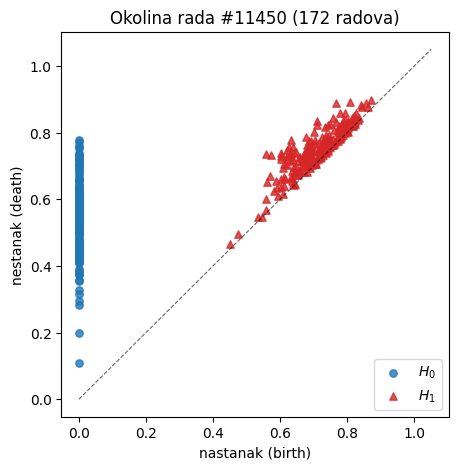

In [7]:
from sklearn.metrics.pairwise import cosine_distances
from gph import ripser_parallel

node = int(np.argmax(F[:, 3]))
nb = adj.indices[adj.indptr[node]:adj.indptr[node + 1]]
ids = np.concatenate(([node], nb))[:200]

D = cosine_distances(X[ids]).astype(np.float64)
dgms = ripser_parallel(D, metric="precomputed", maxdim=1)["dgms"]

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1.05], [0, 1.05], "k--", lw=0.8, alpha=0.6)

for dim, col, mk in [(0, "#1f77b4", "o"), (1, "#d62728", "^")]:
    d = dgms[dim]
    fin = np.isfinite(d[:, 1])
    ax.scatter(d[fin, 0], d[fin, 1], c=col, marker=mk, s=28, alpha=0.8, label=f"$H_{dim}$")

ax.set_xlabel("nastanak (birth)")
ax.set_ylabel("nestanak (death)")
ax.set_title(f"Okolina rada #{node} ({ids.size} radova)")
ax.legend(loc="lower right")
plt.show()

## Modeli sa topološkim feature-ima

Prvo proveravamo koliko signala PH feature-i nose sami, a zatim ih dodajemo tf-idf-u.

In [8]:
rf_ph = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(F[i_tr], y_tr)
report("RF samo na PH feature-ima", y_te, rf_ph.predict(F[i_te]))

RF samo na PH feature-ima
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.2108    0.0575    0.0904       817
           1     0.4095    0.7413    0.5275      1531
           2     0.4615    0.2744    0.3442      1596

    accuracy                         0.4108      3944
   macro avg     0.3606    0.3578    0.3207      3944
weighted avg     0.3894    0.4108    0.3628      3944

Konfuziona matrica (red = stvarno, kolona = predviđeno):
[[  47  579  191]
 [  76 1135  320]
 [ 100 1058  438]]


In [9]:
rf2 = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(Xph[i_tr], y_tr)
report("RF na tf-idf + PH", y_te, rf2.predict(Xph[i_te]))

RF na tf-idf + PH
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.8873    0.8862    0.8867       817
           1     0.8843    0.9282    0.9057      1531
           2     0.9066    0.8640    0.8848      1596

    accuracy                         0.8935      3944
   macro avg     0.8927    0.8928    0.8924      3944
weighted avg     0.8939    0.8935    0.8933      3944

Konfuziona matrica (red = stvarno, kolona = predviđeno):
[[ 724   20   73]
 [  41 1421   69]
 [  51  166 1379]]


In [10]:
imp = rf2.feature_importances_[X.shape[1]:]

print("Značaj PH feature-a u kombinovanom RF:")

for nm, v in sorted(zip(PH_NAMES, imp), key=lambda t: -t[1]):
    print(f"  {nm:8s}: {v:.5f}")

print(f"Ukupan udeo PH feature-a: {imp.sum():.4f}  (od 1.0)")

Značaj PH feature-a u kombinovanom RF:
  sum_H0  : 0.00280
  PE_H0   : 0.00261
  log_deg : 0.00203
  max_H1  : 0.00128
  n_H1    : 0.00105
  PE_H1   : 0.00090
Ukupan udeo PH feature-a: 0.0107  (od 1.0)


## Da li je poboljšanje stvarno? Unakrsna validacija

Na fiksnoj podeli (`random_state=42`) kombinovani model deluje malo bolje. Ali razlika
od pola procenta lako može biti posledica sreće pri jednoj podeli. Zato radimo
uparenu unakrsnu validaciju (`RepeatedStratifiedKFold`, 5 foldova × 2 ponavljanja):
u svakom foldu treniramo oba modela na istim podacima i poredimo ih uparenim t-testom.

In [12]:
from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import ttest_rel

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)
ab, ap, fb, fp = [], [], [], []

for tr, te in cv.split(X, y):
    m1 = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(X[tr], y[tr])
    p1 = m1.predict(X[te])

    m2 = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(Xph[tr], y[tr])
    p2 = m2.predict(Xph[te])

    ab.append(accuracy_score(y[te], p1))
    ap.append(accuracy_score(y[te], p2))

    fb.append(f1_score(y[te], p1, average="macro"))
    fp.append(f1_score(y[te], p2, average="macro"))

ab, ap, fb, fp = map(np.array, (ab, ap, fb, fp))

print(f"tf-idf      : acc {ab.mean():.4f} ± {ab.std():.4f} | macro-F1 {fb.mean():.4f} ± {fb.std():.4f}")
print(f"tf-idf + PH : acc {ap.mean():.4f} ± {ap.std():.4f} | macro-F1 {fp.mean():.4f} ± {fp.std():.4f}")
print(f"prosečna razlika acc: {(ap-ab).mean():+.4f} | +PH bolji u {int((ap>ab).sum())}/{len(ab)} foldova")
print(f"upareni t-test  p(acc) = {ttest_rel(ap, ab).pvalue:.3f} | p(macro-F1) = {ttest_rel(fp, fb).pvalue:.3f}")

tf-idf      : acc 0.8922 ± 0.0041 | macro-F1 0.8915 ± 0.0047
tf-idf + PH : acc 0.8906 ± 0.0047 | macro-F1 0.8897 ± 0.0051
prosečna razlika acc: -0.0016 | +PH bolji u 5/10 foldova
upareni t-test  p(acc) = 0.152 | p(macro-F1) = 0.108


### Zašto? Raspodela PH feature-a po klasama

Ako PH feature-i ne razdvajaju klase, njihove raspodele po klasama biće skoro iste.

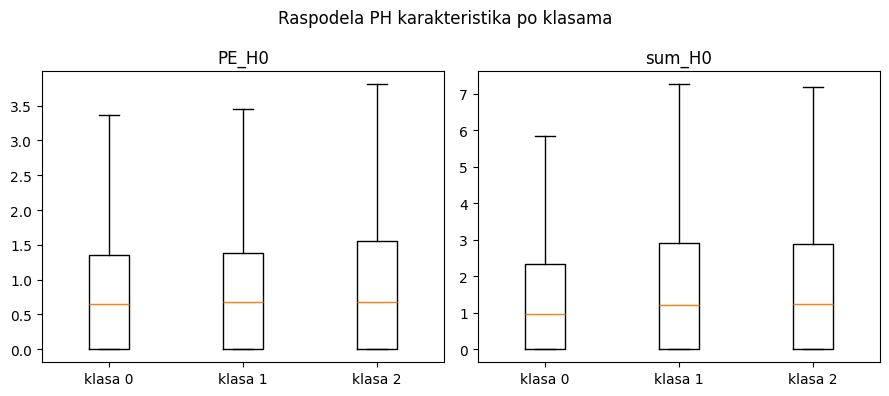

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (nm, ci) in zip(axes, {"PE_H0": 1, "sum_H0": 5}.items()):
    ax.boxplot([F[y == c, ci] for c in range(3)], showfliers=False)
    ax.set_xticklabels(["klasa 0", "klasa 1", "klasa 2"])
    ax.set_title(nm)

fig.suptitle("Raspodela PH karakteristika po klasama")
plt.tight_layout(); plt.show()

### Prvi zaključak (semantička PH)

Perzistentna homologija citatnih okolina jeste legitiman, brz način da se od PubMed
grafa naprave topološki feature-i. Na fiksnoj podeli kombinovani model deluje neznatno
bolji od baseline-a, ali pod unakrsnom validacijom ta razlika nestaje (statistički
neznačajna, čak blago negativna). Uzrok se vidi na dijagramu okoline i na raspodelama
feature-a: okoline nemaju izražene rupe ($H_1$ uz dijagonalu), a raspodele karakteristika
gotovo su iste po klasama. Do sada smo topologiju gradili iz tf-idf rastojanja suseda,
ostaje da probamo da iskoristimo samu strukturu citata.

## Strukturna perzistentna homologija citatnih podgrafova

Prethodni pristup je koristio kosinusna rastojanja tf-idf vektora suseda, semantiku a ne
samu mrežu. Ovde gradimo topologiju isključivo iz žica citata: za svaki rad uzimamo
njegovu 2-hop citatnu ego-mrežu (rad, oni koje citira/koji ga citiraju, i njihovi
susedi), računamo graf-geodezijsko rastojanje unutar podgrafa i nad njim Vietoris–Rips
perzistenciju. Sada $H_1$ hvata citatne petlje (obrasce tipa $i \to a \to c \to b \to i$),
tj. da li se susedi jednog rada i međusobno citiraju.

Napomena: 1-hop ego-mreže su gotovo uvek stabla (nijedna nema $H_1$), pa tek 2-hop otkriva
petlje. Veličinu podgrafa ograničavamo na 150 radova zbog hub-čvorova.

In [14]:
from scipy.sparse.csgraph import shortest_path, connected_components
from gph import ripser_parallel

def ego2_ids(i, adj, max_size=150):
    order = [i]; seen = {i}
    one = adj.indices[adj.indptr[i]:adj.indptr[i + 1]]

    for j in one:
        if len(order) >= max_size:
            break
        seen.add(int(j))
        order.append(int(j))

    for j in list(order[1:]):
        if len(order) >= max_size:
            break
        for k in adj.indices[adj.indptr[j]:adj.indptr[j + 1]]:
            k = int(k)

            if k not in seen:
                seen.add(k)
                order.append(k)
                if len(order) >= max_size:
                    break

    return np.array(order)

def struct_features(i, adj, max_size=150):
    deg = int(adj.indptr[i + 1] - adj.indptr[i])
    ids = ego2_ids(i, adj, max_size)

    if ids.size < 3:
        return np.array([np.log1p(deg), 0, 0, 0, 0, 0], dtype=np.float32)

    sub = adj[ids][:, ids]

    D = shortest_path(sub, directed=False, unweighted=True)

    if not np.isfinite(D).all():
        D[~np.isfinite(D)] = D[np.isfinite(D)].max() + 1.0

    dgms = ripser_parallel(D, metric="precomputed", maxdim=1)["dgms"]
    h0 = dgms[0][:, 1] - dgms[0][:, 0]
    h1 = dgms[1][:, 1] - dgms[1][:, 0] if len(dgms) > 1 and dgms[1].size else np.empty(0)

    fin1 = h1[np.isfinite(h1)]

    return np.array([np.log1p(deg), _entropy(h0), _entropy(h1), float(fin1.size), float(fin1.max()) if fin1.size else 0.0, np.log1p(sub.nnz // 2)], dtype=np.float32)

t0 = time.time()

S = np.vstack(Parallel(n_jobs=-1, batch_size=256)(delayed(struct_features)(i, adj) for i in range(X.shape[0]))).astype(np.float32)

SNAMES = ["log_deg", "sPE_H0", "sPE_H1", "s_nH1", "s_maxH1", "log_edges"]
Xs = np.hstack([X, S])

print(f"strukturne PH karakteristike: {S.shape} za {time.time() - t0:.1f}s")
print(f"udeo čvorova sa bar jednom petljom: {(S[:, 3] > 0).mean():.3f}")

strukturne PH karakteristike: (19717, 6) za 163.5s
udeo čvorova sa bar jednom petljom: 0.443


### Primer strukturnog dijagrama

Geodezijska rastojanja su celobrojna, pa se tačke dijagrama gomilaju; uz svaku pišemo
koliko klasa se poklopi ($×n$). Ovaj rad ima stotine $H_1$ petlji.

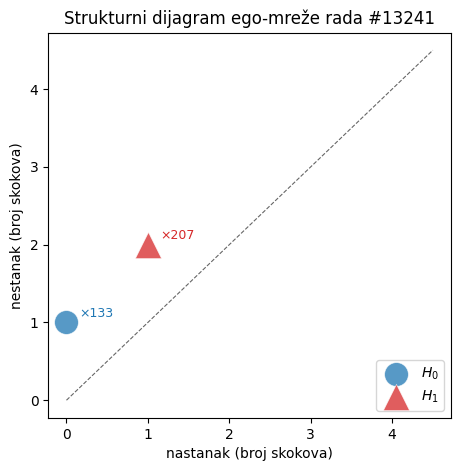

In [15]:
node = int(np.argmax(S[:, 3]))
ids = ego2_ids(node, adj, 150)
sub = adj[ids][:, ids]

D = shortest_path(sub, directed=False, unweighted=True)
dgms = ripser_parallel(D, metric="precomputed", maxdim=1)["dgms"]

fig, ax = plt.subplots(figsize=(5.2, 5))
mx = float(np.max(D[np.isfinite(D)])) + 0.5
ax.plot([0, mx], [0, mx], "k--", lw=0.8, alpha=0.6)

for dim, col, mk in [(0, "#1f77b4", "o"), (1, "#d62728", "^")]:
    d = dgms[dim]; d = d[np.isfinite(d[:, 1])]
    if d.size == 0:
        continue
    pts, cnt = np.unique(d, axis=0, return_counts=True)
    ax.scatter(pts[:, 0], pts[:, 1], s=40 + 22 * np.sqrt(cnt), c=col, marker=mk, alpha=0.75, edgecolors="white", linewidths=0.5, label=f"$H_{dim}$")
    for (b, dd), cc in zip(pts, cnt):
        ax.annotate(f"×{cc}", (b, dd), textcoords="offset points", xytext=(9, 4), fontsize=9, color=col)

ax.set_xlabel("nastanak (broj skokova)")
ax.set_ylabel("nestanak (broj skokova)")
ax.set_title(f"Strukturni dijagram ego-mreže rada #{node}")
ax.legend(loc="lower right")
plt.show()

### Poređenje modela sa strukturnim karakteristikama

In [16]:
rf_so = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(S[i_tr], y_tr)
report("RF samo na strukturnim PH", y_te, rf_so.predict(S[i_te]))

RF samo na strukturnim PH
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.3648    0.2362    0.2868       817
           1     0.4984    0.6218    0.5533      1531
           2     0.5468    0.5157    0.5308      1596

    accuracy                         0.4990      3944
   macro avg     0.4700    0.4579    0.4570      3944
weighted avg     0.4903    0.4990    0.4890      3944

Konfuziona matrica (red = stvarno, kolona = predviđeno):
[[193 371 253]
 [150 952 429]
 [186 587 823]]


In [17]:
rf_s = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(Xs[i_tr], y_tr)
report("RF na tf-idf + strukturna PH", y_te, rf_s.predict(Xs[i_te]))

RF na tf-idf + strukturna PH
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.8796    0.8849    0.8822       817
           1     0.8842    0.9223    0.9028      1531
           2     0.9049    0.8647    0.8843      1596

    accuracy                         0.8912      3944
   macro avg     0.8895    0.8906    0.8898      3944
weighted avg     0.8916    0.8912    0.8911      3944

Konfuziona matrica (red = stvarno, kolona = predviđeno):
[[ 723   22   72]
 [  46 1412   73]
 [  53  163 1380]]


In [18]:
imp = rf_s.feature_importances_[X.shape[1]:]

print("Značaj strukturnih PH feature-a:")

for nm, v in sorted(zip(SNAMES, imp), key=lambda t: -t[1]):
    print(f"  {nm:8s}: {v:.5f}")

print(f"Ukupan udeo strukturnih PH: {imp.sum():.4f}")

Značaj strukturnih PH feature-a:
  log_edges: 0.00505
  sPE_H0  : 0.00465
  s_nH1   : 0.00284
  sPE_H1  : 0.00246
  log_deg : 0.00215
  s_maxH1 : 0.00069
Ukupan udeo strukturnih PH: 0.0178


Zanimljivo: strukturne karakteristike same dovode tačnost na oko 0.50, primetno
iznad većinske klase (~0.40) i iznad semantičke PH. Dakle sama struktura citata nosi
klasni signal. Boks-dijagram pokazuje i jasnu razliku po klasama: klasa 0 ima mnogo manje
petlji (ređe, stablastije citatne mreže) od klasa 1 i 2.

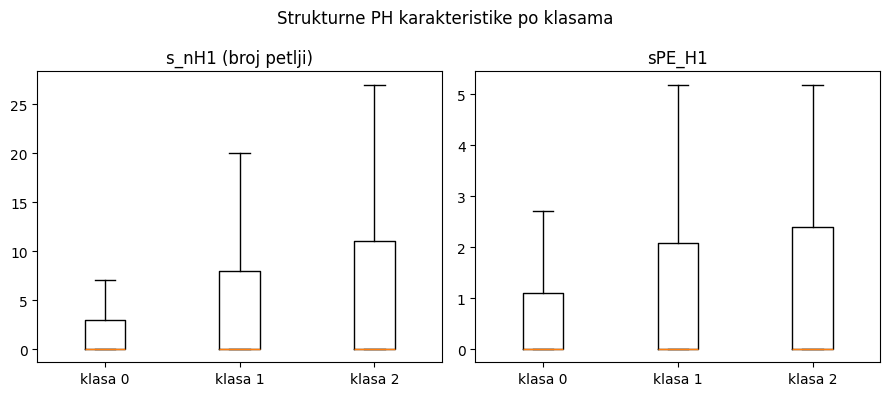

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (nm, ci) in zip(axes, {"s_nH1 (broj petlji)": 3, "sPE_H1": 2}.items()):
    ax.boxplot([S[y == c, ci] for c in range(3)], showfliers=False)
    ax.set_xticklabels(["klasa 0", "klasa 1", "klasa 2"])
    ax.set_title(nm)

fig.suptitle("Strukturne PH karakteristike po klasama")
plt.tight_layout()
plt.show()

Ali da li pomaže povrh tf-idf-a? Ponovo proveravamo uparenom unakrsnom validacijom.

In [20]:
ab, ap, fb, fp = [], [], [], []

for tr, te in RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE).split(X, y):
    p1 = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(X[tr], y[tr]).predict(X[te])
    p2 = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(Xs[tr], y[tr]).predict(Xs[te])

    ab.append(accuracy_score(y[te], p1))
    ap.append(accuracy_score(y[te], p2))

    fb.append(f1_score(y[te], p1, average="macro"))
    fp.append(f1_score(y[te], p2, average="macro"))

ab, ap, fb, fp = map(np.array, (ab, ap, fb, fp))

print(f"tf-idf          : acc {ab.mean():.4f} ± {ab.std():.4f} | macro-F1 {fb.mean():.4f} ± {fb.std():.4f}")
print(f"tf-idf + struct : acc {ap.mean():.4f} ± {ap.std():.4f} | macro-F1 {fp.mean():.4f} ± {fp.std():.4f}")
print(f"Δacc {(ap-ab).mean():+.4f} | +struct bolji u {int((ap>ab).sum())}/{len(ab)} | p(acc)={ttest_rel(ap, ab).pvalue:.3f}")

tf-idf          : acc 0.8922 ± 0.0041 | macro-F1 0.8915 ± 0.0047
tf-idf + struct : acc 0.8905 ± 0.0048 | macro-F1 0.8898 ± 0.0053
Δacc -0.0017 | +struct bolji u 2/10 | p(acc)=0.084


## Deskriptivno poređenje klasa

Umesto klasifikacije, pogledajmo direktno: da li se tri klase topološki razlikuju?
Za svaku klasu gradimo njen indukovani citatni podgraf (strukturna strana) i uzorkujemo
njen tf-idf oblak (semantička strana).

In [21]:
from sklearn.metrics.pairwise import cosine_distances

rng = np.random.default_rng(RANDOM_STATE)

print(f"{'klasa':<6}{'čvorova':>9}{'ivica':>8}{'pros.st.':>10}{'komponenti':>12}")

diag = {}

for c in range(3):
    mask = np.where(y == c)[0]
    sub = adj[mask][:, mask]

    ncomp, _ = connected_components(sub, directed=False)

    print(f"{c:<6}{mask.size:>9}{sub.nnz // 2:>8}{sub.nnz / mask.size:>10.2f}{ncomp:>12}")

    samp = rng.choice(mask, size=min(500, mask.size), replace=False)

    dg = ripser_parallel(cosine_distances(X[samp]).astype(np.float64), metric="precomputed", maxdim=1)["dgms"]
    diag[c] = dg[1][np.isfinite(dg[1]).all(axis=1)] if len(dg) > 1 and dg[1].size else np.empty((0, 2))

klasa   čvorova   ivica  pros.st.  komponenti
0          4103    5212      2.54         842
1          7739   14563      3.76         678
2          7875   15790      4.01        1124


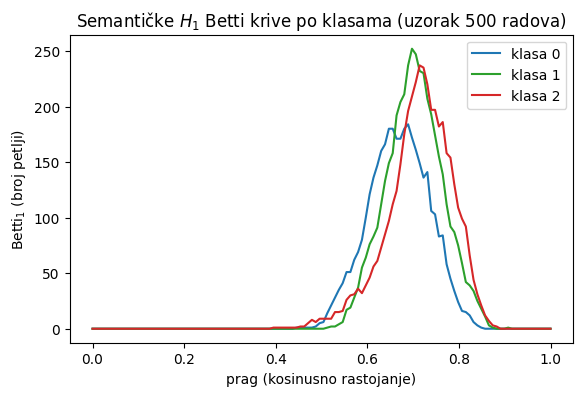

In [22]:
thr = np.linspace(0, 1.0, 120)

def betti1(d):
    return np.zeros_like(thr) if d.size == 0 else np.array([np.sum((d[:, 0] <= t) & (t < d[:, 1])) for t in thr])

fig, ax = plt.subplots(figsize=(6.5, 4))

for c, col in zip(range(3), ["#1f77b4", "#2ca02c", "#d62728"]):
    ax.plot(thr, betti1(diag[c]), color=col, label=f"klasa {c}")

ax.set_xlabel("prag (kosinusno rastojanje)")
ax.set_ylabel("Betti$_1$ (broj petlji)")
ax.set_title("Semantičke $H_1$ Betti krive po klasama (uzorak 500 radova)")
ax.legend()
plt.show()

## Proširenja: bogatiji feature-i, pretraga i objedinjeni model

Do sada su topološki feature-i bili šest skalara (entropija + deskriptori) ili strukturni
skalari. Ovde idemo dalje u tri pravca: (1) prava vektorizacija dijagrama preko
Persistence Image, (2) pretraga po definiciji okoline i tipu feature-a, i (3)
objedinjeni model sa svim TDA feature-ima zajedno.

In [23]:
from gtda.diagrams import PersistenceImage
from sklearn.metrics.pairwise import cosine_distances

def semantic_diagram(i, hops, max_nb=200):
    if hops == 1:
        nb = adj.indices[adj.indptr[i]:adj.indptr[i + 1]]
        ids = np.concatenate(([i], nb))[:max_nb]
    else:
        ids = ego2_ids(i, adj, max_nb)
    if ids.size < 3:
        return np.zeros((0, 3))

    D = cosine_distances(X[ids]).astype(np.float64)
    dgms = ripser_parallel(D, metric="precomputed", maxdim=1)["dgms"]

    rows = []

    for dim, d in enumerate(dgms):
        for b, de in d:
            if np.isfinite(de) and de > b:
                rows.append([b, de, float(dim)])

    return np.array(rows) if rows else np.zeros((0, 3))

def build_pi(hops, n_bins=5, cap_h0=120, cap_h1=80):
    diags = Parallel(n_jobs=-1, batch_size=256)( delayed(semantic_diagram)(i, hops) for i in range(X.shape[0]))

    H0, H1 = [], []

    for d in diags:
        h0 = d[d[:, 2] == 0]; h1 = d[d[:, 2] == 1]
        if h0.shape[0] > cap_h0:
            h0 = h0[np.argsort(h0[:, 1] - h0[:, 0])[::-1][:cap_h0]]
        if h1.shape[0] > cap_h1:
            h1 = h1[np.argsort(h1[:, 1] - h1[:, 0])[::-1][:cap_h1]]
        H0.append(h0)
        H1.append(h1)

    n0 = max(1, max(h.shape[0] for h in H0))
    n1 = max(1, max(h.shape[0] for h in H1))
    arr = np.zeros((X.shape[0], n0 + n1, 3))
    arr[:, n0:, 2] = 1.0

    for k in range(X.shape[0]):
        if H0[k].shape[0]:
            arr[k, :H0[k].shape[0]] = H0[k]
        if H1[k].shape[0]:
            arr[k, n0:n0 + H1[k].shape[0]] = H1[k]

    return PersistenceImage(n_bins=n_bins, n_jobs=-1).fit_transform(arr).reshape(X.shape[0], -1).astype(np.float32)

def cv_acc(feat, splits=5, repeats=1):
    Z = np.hstack([X, feat]) if feat is not None else X
    a = []

    for tr, te in RepeatedStratifiedKFold(n_splits=splits, n_repeats=repeats, random_state=RANDOM_STATE).split(X, y):
        a.append(accuracy_score(y[te], RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(Z[tr], y[tr]).predict(Z[te])))

    return float(np.mean(a)), float(np.std(a))

### (1) Persistence Image vektorizacija

Umesto šest skalara, svaki dijagram pretvaramo u zaglađenu 2D sliku (birth × persistence),
zasebno za $H_0$ i $H_1$, pa je izravnamo u vektor od 50 brojeva, što je mnogo bogatiji opis
lokalne topologije.

In [24]:
PI1 = build_pi(hops=1)

print("Persistence Image feature-i:", PI1.shape)

b = cv_acc(None, repeats=2); p = cv_acc(PI1, repeats=2)

print(f"tf-idf           : acc {b[0]:.4f} ± {b[1]:.4f}")
print(f"tf-idf + PImage  : acc {p[0]:.4f} ± {p[1]:.4f}")

Persistence Image feature-i: (19717, 50)
tf-idf           : acc 0.8922 ± 0.0041
tf-idf + PImage  : acc 0.8902 ± 0.0051


Bogatija reprezentacija ne pomaže, čak je neznatno lošija. Slika dijagrama sadrži isti
(slab) signal kao i entropija, samo u više dimenzija.

### (2) Pretraga po okolini i tipu feature-a

Poredimo četiri konfiguracije semantičkih feature-a (1-hop/2-hop × entropija/slika) sa
baseline-om, petostrukom unakrsnom validacijom. `F` (1-hop entropija) je već izračunato ranije.

In [25]:
PI2 = build_pi(hops=2)

def entropy2(i):
    ids = ego2_ids(i, adj, 200); deg = int(adj.indptr[i + 1] - adj.indptr[i])

    if ids.size < 3:
        return np.array([np.log1p(deg), 0, 0, 0, 0, 0], np.float32)

    D = cosine_distances(X[ids]).astype(np.float64)
    dg = ripser_parallel(D, metric="precomputed", maxdim=1)["dgms"]

    h0 = dg[0][:, 1] - dg[0][:, 0]
    h1 = dg[1][:, 1] - dg[1][:, 0] if len(dg) > 1 and dg[1].size else np.empty(0)
    fin1 = h1[np.isfinite(h1)]

    return np.array([np.log1p(deg), _entropy(h0), _entropy(h1), float(fin1.size), float(fin1.max()) if fin1.size else 0.0, float(h0[np.isfinite(h0)].sum())], np.float32)

F2 = np.vstack(Parallel(n_jobs=-1, batch_size=256)(delayed(entropy2)(i) for i in range(X.shape[0])))

configs = {"tf-idf (baseline)": None, "1-hop entropija": F, "2-hop entropija": F2, f"1-hop image ({PI1.shape[1]})": PI1, f"2-hop image ({PI2.shape[1]})": PI2}

print(f"{'konfiguracija':<26}{'CV tačnost':>16}")

for nm, ft in configs.items():
    mu, sd = cv_acc(ft, splits=5, repeats=1)

    print(f"{nm:<26}{mu:.4f} ± {sd:.4f}")

konfiguracija                   CV tačnost
tf-idf (baseline)         0.8934 ± 0.0032
1-hop entropija           0.8908 ± 0.0050
2-hop entropija           0.8907 ± 0.0035
1-hop image (50)          0.8901 ± 0.0047
2-hop image (50)          0.8889 ± 0.0032


Nijedna konfiguracija ne prelazi baseline. Ni više hopova ni bogatija slika ne prelaze, svi topološki feature-i ostaju blago ispod čistog tf-idf-a.

### (3) Objedinjeni TDA model

Poslednji, „najjači" pokušaj: tf-idf plus sve topološke reprezentacije zajedno:
semantička entropija ($F$), strukturna PH ($S$) i Persistence Image ($PI2$).

In [26]:
UNI = np.hstack([F, S, PI2])

print("objedinjeni TDA blok:", UNI.shape[1], "kolona uz", X.shape[1], "tf-idf kolona")

b = cv_acc(None, repeats=2); u = cv_acc(UNI, repeats=2)

print(f"tf-idf             : acc {b[0]:.4f} ± {b[1]:.4f}")
print(f"tf-idf + svi TDA   : acc {u[0]:.4f} ± {u[1]:.4f}")

Z = np.hstack([X, UNI])
report("RF na tf-idf + svi TDA feature-i (objedinjeno)", y_te, RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(Z[i_tr], y_tr).predict(Z[i_te]))

objedinjeni TDA blok: 62 kolona uz 500 tf-idf kolona
tf-idf             : acc 0.8922 ± 0.0041
tf-idf + svi TDA   : acc 0.8868 ± 0.0038
RF na tf-idf + svi TDA feature-i (objedinjeno)
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.8872    0.8764    0.8818       817
           1     0.8800    0.9242    0.9016      1531
           2     0.8993    0.8615    0.8800      1596

    accuracy                         0.8889      3944
   macro avg     0.8888    0.8874    0.8878      3944
weighted avg     0.8893    0.8889    0.8887      3944

Konfuziona matrica (red = stvarno, kolona = predviđeno):
[[ 716   23   78]
 [  40 1415   76]
 [  51  170 1375]]


Objedinjeni model je najlošiji od svih, dodavanjem preko 60 slabo-informativnih,
međusobno redundantnih kolona uz 500 tf-idf kolona samo otežavamo slučajnoj šumi da napravi
dobre podele.

## Zaključak

Isprobali smo tri topološka ugla na istom PubMed skupu: mapper (hibrid strukture i teksta),
semantičku PH okolina i strukturnu PH citatnih mreža, i zatim pojačali feature inženjering
(Persistence Image vektorizacija, pretraga po okolini, objedinjeni model). Nalaz je dosledan:

- Sama struktura citata nosi signal, strukturna PH sama daje ~0.50 tačnosti, a klase se
  vidljivo razlikuju po broju citatnih petlji (klasa 0 je najređe povezana).
- Ali povrh tf-idf-a nijedan pristup ne donosi robusno poboljšanje, ni bogatija
  vektorizacija (Persistence Image), ni objedinjeni model sa svim TDA feature-ima. Objedinjeni
  model je čak najlošiji: gomilanje slabo-informativnih, redundantnih kolona uz 500-dimenzioni
  tf-idf samo razblažuje podele slučajne šume.

Razlog je to što radovi obično citiraju druge radove iz iste oblasti, pa i njihova povezanost citatima i njihov raspored u prostoru reči govore uglavnom o temi rada, a baš tu informaciju tf-idf vektor već sadrži. Topologija ovde ne otkriva ništa novo, već isti signal samo prikazuje na drugi način. To je i pouka: TDA je moćan alat, ali njegova vrednost zavisi od toga postoji li u podacima topološka struktura koju druge reprezentacije ne hvataju.